NOTE: Code end at cell 20 from EDA...Using "cleaned_sp500.csv" for continued analysis

## Importing Libraries

In [82]:
# Loading Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import time
# import gdelt
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, log_loss, brier_score_loss, precision_score, recall_score, f1_score
)

import pandas_ta as ta
import xgboost as xgb
from sklearn.model_selection import train_test_split

# Set plotting style for EDA
sns.set_theme(style="whitegrid")

### Loading Dataset

In [46]:
# Creating dataframe from .csv
sp500_original = pd.read_csv('final_sp500_data.csv')
# sp500_original = pd.read_csv("cleaned_sp500.csv", parse_dates=["Date"]).set_index(["Ticker", "Ticker"]).sort_index()

sp500_original.head()

,Date,Ticker,Company,Sector,Industry,Open,High,Low,Close,Volume,avg_sentiment,article_count
0,2021-07-15,PCAR,Paccar Inc,Industrials,Construction Machinery & Heavy Transportation ...,49.837958,50.460862,49.628436,50.024830,2752650,1.672467,3
1,2021-07-16,PCAR,Paccar Inc,Industrials,Construction Machinery & Heavy Transportation ...,49.928565,50.449540,49.543499,49.611450,2798850,2.251032,2
2,2021-07-19,PCAR,Paccar Inc,Industrials,Construction Machinery & Heavy Transportation ...,49.084803,49.492521,48.829979,49.101791,3898500,0.000000,0
3,2021-07-20,PCAR,Paccar Inc,Industrials,Construction Machinery & Heavy Transportation ...,49.186736,50.324951,49.005528,49.883255,2599200,0.000000,0
4,2021-07-21,PCAR,Paccar Inc,Industrials,Construction Machinery & Heavy Transportation ...,49.911572,50.585442,49.815308,49.917236,1934250,0.000000,0


In [47]:
# # Info
# sp500_original = sp500_original.sort_values(by=['Ticker', 'Date'])
# sp500_original = sp500_original.reset_index(drop=True)

# sp500_original.head()
# sp500_original.to_csv('final_sp500.csv', index=False)

# unique_tickers = sp500_original["Ticker"].unique()
# print("Total Tickers (Companies): ", len(unique_tickers))
# print(sp500_original.shape[0], " x ", sp500_original.shape[1]) 
# sp500_original.columns

# missing_values = sp500_original.isnull().sum()
# print(missing_values)

# sp500_original['avg_sentiment'] = sp500_original['avg_sentiment'].fillna(0)
# # sp500_original[sp500_original.isnull().any(axis=1)].head()

# missing_values = sp500_original.isnull().sum()
# print(missing_values)
# sp500_original.to_csv('final_sp500.csv', index=False)

In [48]:
# Converting data types
sp500_original['Date'] = pd.to_datetime(sp500_original['Date'])
sp500_original['Sector'] = sp500_original['Sector'].astype('category')
sp500_original['Industry'] = sp500_original['Industry'].astype('category')

# Sort by Ticker, then Date
sp500_original = sp500_original.sort_values(by=['Ticker', 'Date'])
sp500_original.head()


,Date,Ticker,Company,Sector,Industry,Open,High,Low,Close,Volume,avg_sentiment,article_count
234465,2010-01-04,A,Agilent Technologies Inc,Health Care,Life Sciences Tools & Services,19.948872,20.101397,19.783637,19.891676,3815561,0.0,0
234466,2010-01-05,A,Agilent Technologies Inc,Health Care,Life Sciences Tools & Services,19.834482,19.840836,19.548498,19.675602,4186031,0.0,0
234467,2010-01-06,A,Agilent Technologies Inc,Health Care,Life Sciences Tools & Services,19.605700,19.701027,19.548502,19.605700,3243779,0.0,0
234468,2010-01-07,A,Agilent Technologies Inc,Health Care,Life Sciences Tools & Services,19.561209,19.586631,19.383265,19.580276,3095172,0.0,0
234469,2010-01-08,A,Agilent Technologies Inc,Health Care,Life Sciences Tools & Services,19.472230,19.605689,19.319706,19.573912,3733918,0.0,0


## EDA

### Unique Values

In [49]:
# Info
unique_tickers = sp500_original["Ticker"].unique()
print("Total Tickers (Companies): ", len(unique_tickers))
print(sp500_original.shape[0], " x ", sp500_original.shape[1]) 
sp500_original.columns

unique_counts = pd.DataFrame({
    'Column': sp500_original.columns,
    'Unique': sp500_original.nunique().values,
    'Data_Type': sp500_original.dtypes.values,
    'Sample_Values': [sp500_original[col].unique().tolist() for col in sp500_original.columns]
})

print(unique_counts.shape)
unique_counts

Total Tickers (Companies):  503
1883792  x  12
(12, 4)


,Column,Unique,Data_Type,Sample_Values
0,Date,3989,datetime64[ns],"[2010-01-04 00:00:00, 2010-01-05 00:00:00, 201..."
1,Ticker,503,object,"[A, AAPL, ABBV, ABNB, ABT, ACGL, ACN, ADBE, AD..."
2,Company,503,object,"[Agilent Technologies Inc, Apple Inc, AbbVie I..."
3,Sector,11,category,"[Health Care, Information Technology, Consumer..."
4,Industry,129,category,"[Life Sciences Tools & Services, Technology Ha..."
5,Open,1655353,float64,"[19.94887170398882, 19.83448151446589, 19.6056..."
6,High,1658302,float64,"[20.101396541348887, 19.840836222190536, 19.70..."
7,Low,1657181,float64,"[19.78363745202544, 19.54849763720313, 19.5485..."
8,Close,1539422,float64,"[19.89167594909668, 19.67560195922852, 19.6056..."
9,Volume,382897,int64,"[3815561, 4186031, 3243779, 3095172, 3733918, ..."


### Missing Values (Initial) and Heatmap of Missing Values

Missing Values per column:
Series([], dtype: int64)


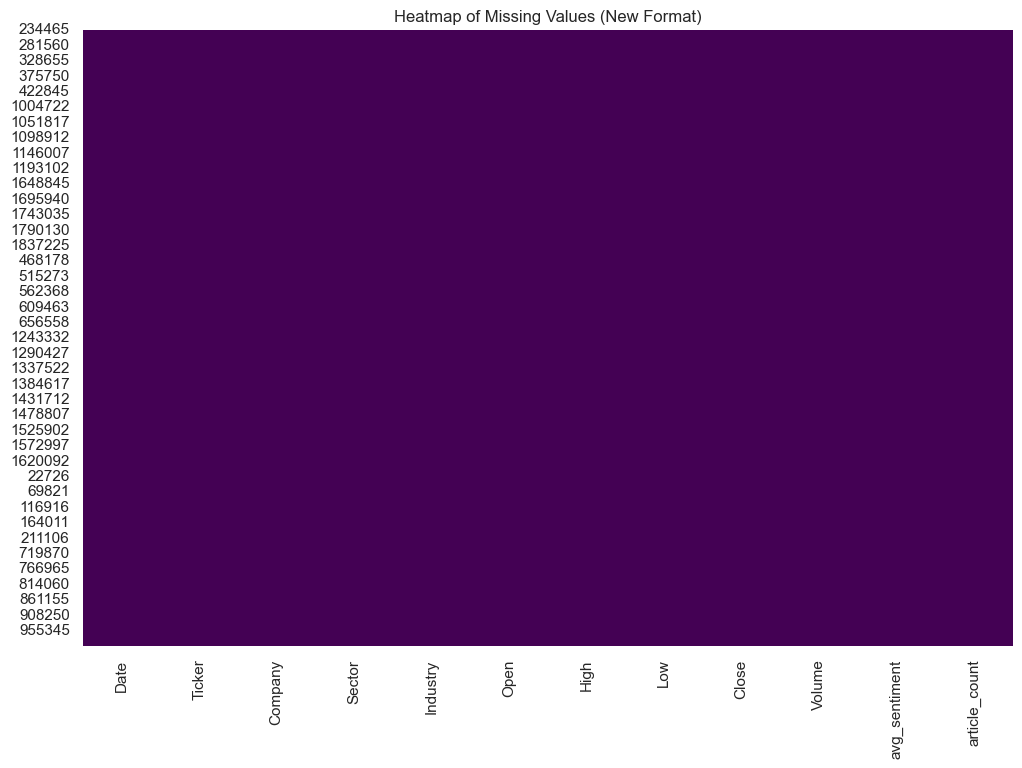

In [50]:
missing = sp500_original.isnull().sum()
print("Missing Values per column:")
print(missing[missing > 0])

# Create a heatmap of missing values
plt.figure(figsize=(12, 8))
sns.heatmap(sp500_original.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap of Missing Values (New Format)')
plt.show()


## Feature Engineering

Additional columns are added prior to GDELT cutoff date.

In [ ]:
# Creating seperate dataframe for analysis
df = sp500_original.copy()

# Get the percentage change of price and volume
df['daily_return'] = df.groupby('Ticker')['Close'].pct_change()

# Get the percentage change of price and volume over 5 day period
df['returns(-1)'] = 
df['returns(-2)'] = 
df['returns(-3)'] = 
df['returns(-4)'] = 
df['returns(-5)'] = 

# weekly, monthly, quarterly, and yearly returns (in business trading days)
df['weekly_return'] = df.groupby('Ticker')['Close'].pct_change(periods=5) # 1 week (5 days)
df['monthly_return'] = df.groupby('Ticker')['Close'].pct_change(periods=21) # 1 month (21 days)
df['quarterly_return'] = df.groupby('Ticker')['Close'].pct_change(periods=63) # 3 months (63 days)
df['yearly_return'] = df.groupby('Ticker')['Close'].pct_change(periods=252) # 3 months (252 days)

df['daily_vol'] = df.groupby('Ticker')['Volume'].pct_change()

# weekly, monthly, quarterly, and yearly returns (in business trading days)
df['weekly_vol'] = df.groupby('Ticker')['Volume'].pct_change(periods=5) # 1 week (5 days)
df['monthly_vol'] = df.groupby('Ticker')['Volume'].pct_change(periods=21) # 1 month (21 days)
df['quarterly_vol'] = df.groupby('Ticker')['Volume'].pct_change(periods=63) # 3 months (63 days)
df['yearly_vol'] = df.groupby('Ticker')['Volume'].pct_change(periods=252) # 3 months (252 days)

df.dropna(inplace=True)

df['daily_price_direction'] = np.sign(df['daily_return']).astype(int)
df['daily_volume_direction'] = np.sign(df['daily_vol']).astype(int)

df['target_next_day_direction'] = (df.groupby('Ticker')['Close'].shift(-1) > df['Close']).astype(int)

# GDELT 2.0 has data as early as February 19, 2025. Earlier dates are removed from analysis.
gdelt_cutoff_date = pd.to_datetime('2015-02-19')
df = df[df['Date'] >= gdelt_cutoff_date]

# Reset the final index
df.reset_index(drop=True, inplace=True)

# Display dataframe for verification
df.head()

,Date,Ticker,Company,Sector,Industry,Open,High,Low,Close,Volume,avg_sentiment,article_count,daily_return,daily_vol,daily_price_direction,daily_volume_direction,target_next_day_direction
0,2015-02-19,A,Agilent Technologies Inc,Health Care,Life Sciences Tools & Services,37.889730,38.045314,37.560253,37.660927,3737300,-0.884512,3,-0.009388,-0.585076,-1,-1,1
1,2015-02-20,A,Agilent Technologies Inc,Health Care,Life Sciences Tools & Services,37.606019,38.539534,37.413825,38.393101,2971900,0.590905,2,0.019441,-0.204800,1,-1,0
2,2015-02-23,A,Agilent Technologies Inc,Health Care,Life Sciences Tools & Services,38.338183,38.402248,37.972101,38.191750,1967900,0.000000,1,-0.005244,-0.337831,-1,-1,1
3,2015-02-24,A,Agilent Technologies Inc,Health Care,Life Sciences Tools & Services,38.091068,38.539523,38.072763,38.493763,1922100,0.351906,1,0.007908,-0.023274,1,-1,1
4,2015-02-25,A,Agilent Technologies Inc,Health Care,Life Sciences Tools & Services,38.750024,38.887307,38.521221,38.621895,2343500,-0.291386,3,0.003329,0.219239,1,1,1


In [52]:
# --- Daily Price Direction ---
price_counts = df['daily_price_direction'].value_counts()
price_percentages = df['daily_price_direction'].value_counts(normalize=True) * 100

# Combine into a DataFrame
price_summary = pd.DataFrame({
    'Count': price_counts,
    'Percentage': price_percentages.map('{:.2f}%'.format)
})

# Reset the index to turn it into a column, then rename the new column
price_summary = price_summary.reset_index().rename(columns={'index': 'Direction'})

print("\n--- Daily Price Direction ---")
# Use to_string(index=False) to print without the index
print(price_summary.to_string(index=False))

# --- Daily Volume Direction ---
volume_counts = df['daily_volume_direction'].value_counts()
volume_percentages = df['daily_volume_direction'].value_counts(normalize=True) * 100

# Combine into a DataFrame
volume_summary = pd.DataFrame({
    'Count': volume_counts,
    'Percentage': volume_percentages.map('{:.2f}%'.format)
})

# Reset the index and rename the new column
volume_summary = volume_summary.reset_index().rename(columns={'index': 'Direction'})

print("\n--- Daily Volume Direction ---")
# Use to_string(index=False) to print without the index
print(volume_summary.to_string(index=False))


--- Daily Price Direction ---
 daily_price_direction  Count Percentage
                     1 685861     52.34%
                    -1 617885     47.16%
                     0   6550      0.50%

--- Daily Volume Direction ---
 daily_volume_direction  Count Percentage
                     -1 673879     51.43%
                      1 636112     48.55%
                      0    305      0.02%


## Time Frame settings

In [53]:
# Find the most recent date in the DataFrame
last_date = df['Date'].max()

# Calculate the date 5 years ago from the last date
five_years_ago = last_date - pd.DateOffset(years=5)

# Create a new DataFrame containing only the data from the last 5 years
df_timeframe = df[df['Date'] >= five_years_ago].copy()

print(f"Original df has data from {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"New df has data from {df_timeframe['Date'].min().date()} to {df_timeframe['Date'].max().date()}\n")


Original df has data from 2015-02-19 to 2025-11-10
New df has data from 2020-11-10 to 2025-11-10



## Summary Statistics

In [54]:
# Summary Statistics

# Columns to Summarize
# columns_to_summarize = ['daily_return', 'daily_vol']
columns_to_summarize = ['daily_vol']

# Group by 'Ticker' and calculate descriptive statistics for the selected columns
summary_ticker = df_timeframe.groupby('Ticker')[columns_to_summarize].describe()
summary_sector = df_timeframe.groupby('Sector')[columns_to_summarize].describe()
summary_industry = df_timeframe.groupby('Industry')[columns_to_summarize].describe()


C:\Users\jplac\AppData\Local\Temp\ipykernel_19184\2898511075.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_sector = df_timeframe.groupby('Sector')[columns_to_summarize].describe()
C:\Users\jplac\AppData\Local\Temp\ipykernel_19184\2898511075.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_industry = df_timeframe.groupby('Industry')[columns_to_summarize].describe()


In [55]:
# print(summary_sector.loc['Information Technology'])
summary_sector

daily_vol                                             \
                           count      mean          std       min       25%   
Sector                                                                        
Communication Services   30144.0  0.093116     0.585307 -0.921695 -0.209351   
Consumer Discretionary   61501.0  0.074827     0.479477 -0.938187 -0.200305   
Consumer Staples         45848.0  0.083016     0.780810 -0.990953 -0.200887   
Energy                   27569.0  0.074462     0.497921 -0.944313 -0.193141   
Financials               93914.0  0.080662     0.604791 -0.990363 -0.202558   
Health Care              73983.0  0.089413     0.865190 -0.993423 -0.211475   
Industrials              97646.0  0.083164     0.514316 -0.958760 -0.210045   
Information Technology   85311.0  0.085176     0.540602 -0.957824 -0.210916   
Materials                30976.0  7.413336  1277.587583 -0.998788 -0.211584   
Real Estate              38936.0  0.084804     0.520936 -0.932682 -0.207269   
Utilities                38636.0  0.082217     0.636006 -0.890548 -0.203822   

                                                           
                             50%       75%            max  
Sector                                                     
Communication Services -0.016454  0.244329      17.974711  
Consumer Discretionary -0.013699  0.234163      17.506200  
Consumer Staples       -0.013409  0.232450     125.014286  
Energy                 -0.011201  0.221502      16.088907  
Financials             -0.011543  0.236041      80.939439  
Health Care            -0.012328  0.248696     184.493827  
Industrials            -0.011772  0.249008      17.035345  
Information Technology -0.013149  0.251062      36.614867  
Materials              -0.012807  0.251470  224854.666667  
Real Estate            -0.008488  0.247684      12.439327  
Utilities              -0.009146  0.245401      78.855756

In [ ]:
# # Feature Engineering: SMA, RSI, MACD, Boiller Bands
#  df = sp500_original.copy()

# # Group by Ticker to perform calculations per stock
# grouped = df.groupby('Ticker')

# # --- Corrected Pattern for Single-Column Indicators ---
# df['SMA_3d'] = grouped['Close'].apply(lambda x: ta.sma(x, length=3)).reset_index(level=0, drop=True)
# df['SMA_5d'] = grouped['Close'].apply(lambda x: ta.sma(x, length=5)).reset_index(level=0, drop=True)
# df['SMA_20d'] = grouped['Close'].apply(lambda x: ta.sma(x, length=20)).reset_index(level=0, drop=True)
# df['SMA_50d'] = grouped['Close'].apply(lambda x: ta.sma(x, length=50)).reset_index(level=0, drop=True)
# df['RSI_14d'] = grouped['Close'].apply(lambda x: ta.rsi(x, length=14)).reset_index(level=0, drop=True)

# # --- Robust Function for Multi-Column Indicators ---
# # This function now checks if the indicators are None before trying to combine them.
# def apply_ta_indicators(group):
#     # Calculate indicators
#     macd = ta.macd(group['Close'], fast=12, slow=26, signal=9)
#     bbands = ta.bbands(group['Close'], length=20)
    
#     # Create a list of indicators that are not None
#     indicators_to_concat = []
#     if macd is not None:
#         indicators_to_concat.append(macd)
#     if bbands is not None:
#         indicators_to_concat.append(bbands)
        
#     # If the list is not empty, concatenate them. Otherwise, return None.
#     if indicators_to_concat:
#         return pd.concat(indicators_to_concat, axis=1)
#     else:
#         return None

# # Apply the robust function
# indicator_df = grouped.apply(apply_ta_indicators)

# # Drop the top level of the MultiIndex created by apply
# indicator_df.reset_index(level=0, drop=True, inplace=True)

# # Join the results back to the main DataFrame
# df = df.join(indicator_df)

# # Add momentum features
# df['daily_return'] = df.groupby('Ticker')['Close'].pct_change()
# df['vol_change'] = df.groupby('Ticker')['Volume'].pct_change()

# # Define the Target Variable
# df['target'] = (df.groupby('Ticker')['Close'].shift(-1) > df['Close']).astype(int)

# # Drop all rows with any NaN values from any step
# df.dropna(inplace=True)

# # Reset the final index
# df.reset_index(drop=True, inplace=True)


# print(df.columns)

# missing = df.isnull().sum()
# print("Missing Values per column:")
# print(missing[missing > 0])

# print(df.shape[0], " x ", df.shape[1]) 

# df.head()

### Sector Comparison

C:\Users\jplac\AppData\Local\Temp\ipykernel_19184\1813896104.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_5_sectors = df_timeframe.groupby('Sector')['article_count'].sum().index.tolist()


Top 5 Sectors by Article Volume: ['Communication Services', 'Consumer Discretionary', 'Consumer Staples', 'Energy', 'Financials', 'Health Care', 'Industrials', 'Information Technology', 'Materials', 'Real Estate', 'Utilities']


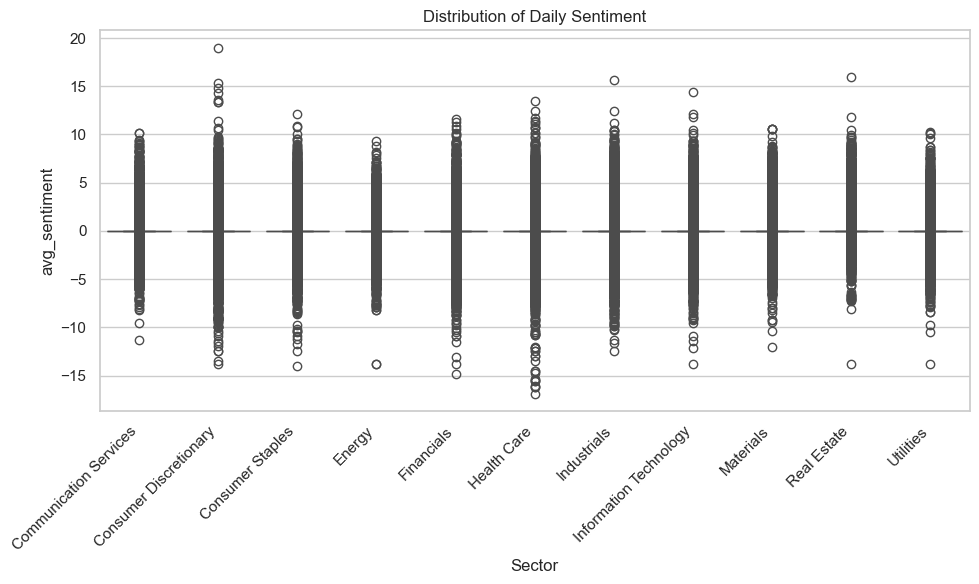

In [57]:
# Identify Top 5 Sectors by total article volume
top_5_sectors = df_timeframe.groupby('Sector')['article_count'].sum().index.tolist()
print(f"Top 5 Sectors by Article Volume: {top_5_sectors}")

# Filter the dataset for only these top 5 sectors
df_sector = df_timeframe[df_timeframe['Sector'].isin(top_5_sectors)]

# Compare Average Sentiment across Top 5 Sectors
plt.figure(figsize=(10, 6))
sns.boxplot(x='Sector', y='avg_sentiment', data=df_sector)
plt.title('Distribution of Daily Sentiment')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

C:\Users\jplac\AppData\Local\Temp\ipykernel_19184\2121054806.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sector_volatility = df_sector.groupby('Sector')['daily_return'].std().reset_index()


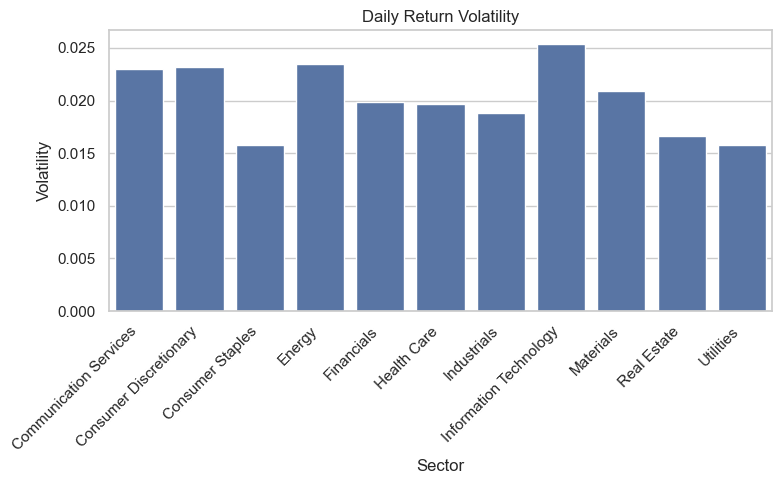

In [58]:
# Compare Volatility (Risk) across Top 5 Sectors
# Volatility is calculated as the standard deviation of daily returns
sector_volatility = df_sector.groupby('Sector')['daily_return'].std().reset_index()
sector_volatility.rename(columns={'daily_return': 'Volatility'}, inplace=True)

plt.figure(figsize=(8, 5))
sns.barplot(x='Sector', y='Volatility', data=sector_volatility)
plt.title('Daily Return Volatility')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

C:\Users\jplac\AppData\Local\Temp\ipykernel_19184\3179655261.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_10_industries = df_timeframe.groupby('Industry')['article_count'].sum().nlargest(10).index.tolist()
C:\Users\jplac\AppData\Local\Temp\ipykernel_19184\3179655261.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


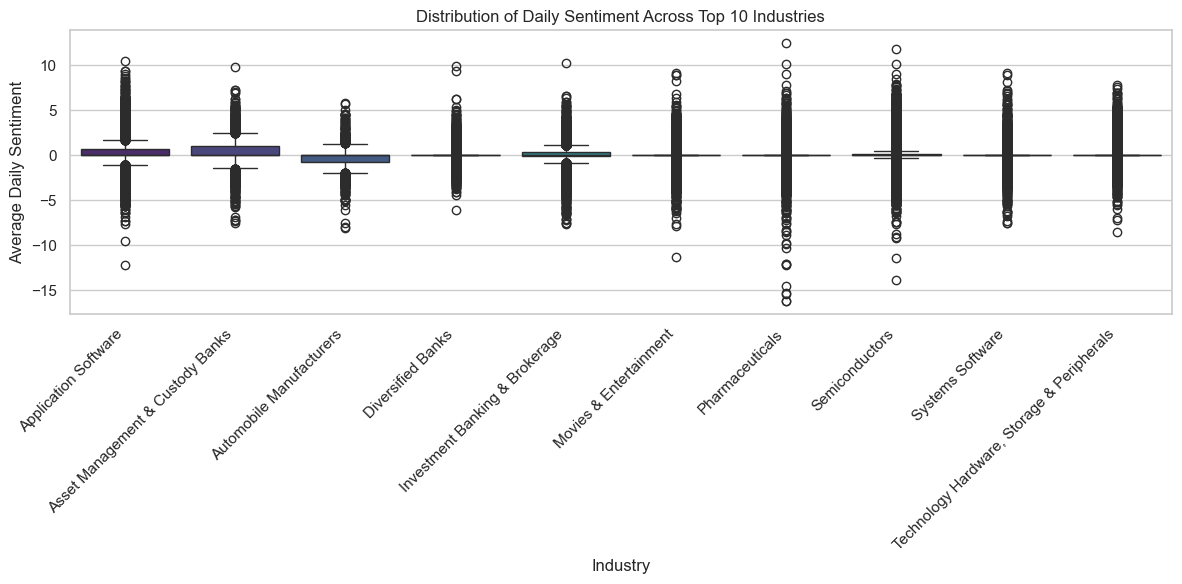

In [59]:
# Identify the Top 10 Industries by total article volume
top_10_industries = df_timeframe.groupby('Industry')['article_count'].sum().nlargest(10).index.tolist()

# Filter the dataset and make a copy to avoid warnings
df_top10_ind = df_timeframe[df_timeframe['Industry'].isin(top_10_industries)].copy()

# Fix the x-axis text overlap by converting to standard strings
df_top10_ind['Industry'] = df_top10_ind['Industry'].astype(str)

# Calculate the median sentiment for these top 10 to sort the plot
industry_order = df_top10_ind.groupby('Industry')['avg_sentiment'].median().sort_values(ascending=False).index

# Create the improved boxplot WITH the outlier dots
plt.figure(figsize=(12, 6))

sns.boxplot(
    x='Industry', 
    y='avg_sentiment', 
    data=df_top10_ind, 
    order=industry_order, 
    palette='viridis'
    # showfliers=False has been removed, so the dots will return!
)

plt.title('Distribution of Daily Sentiment Across Top 10 Industries')
plt.xticks(rotation=45, ha='right') 
plt.ylabel('Average Daily Sentiment')
plt.tight_layout()
plt.show()

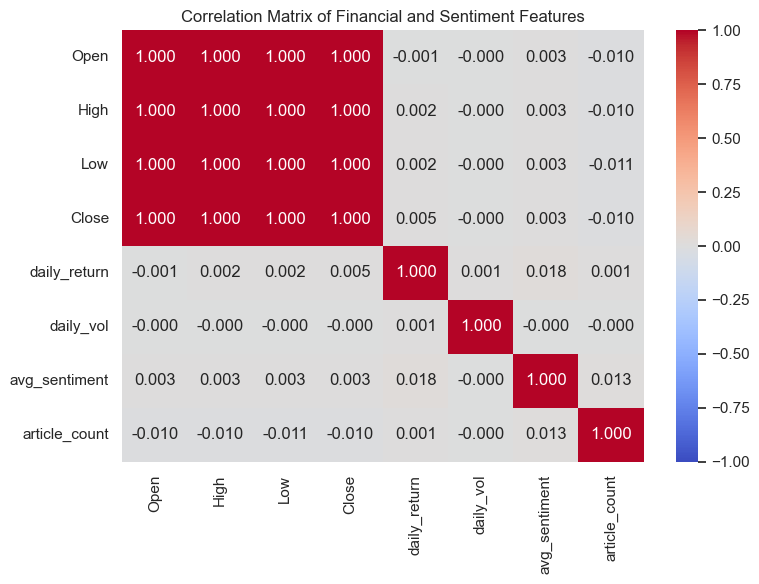

In [60]:
# Select numerical columns for correlation
cols_to_correlate = ['daily_return', 'daily_vol', 'avg_sentiment', 'article_count']

# Calculate correlation matrix
corr_matrix = df_timeframe[['Open', 'High', 'Low', 'Close', 'daily_return', 'daily_vol', 'avg_sentiment', 'article_count']].corr()

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".3f")
plt.title('Correlation Matrix of Financial and Sentiment Features')
plt.tight_layout()
plt.show()

C:\Users\jplac\AppData\Local\Temp\ipykernel_19184\497240182.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  daily_sector_articles = df_timeframe.groupby(['Date', 'Sector'])['article_count'].sum().reset_index()


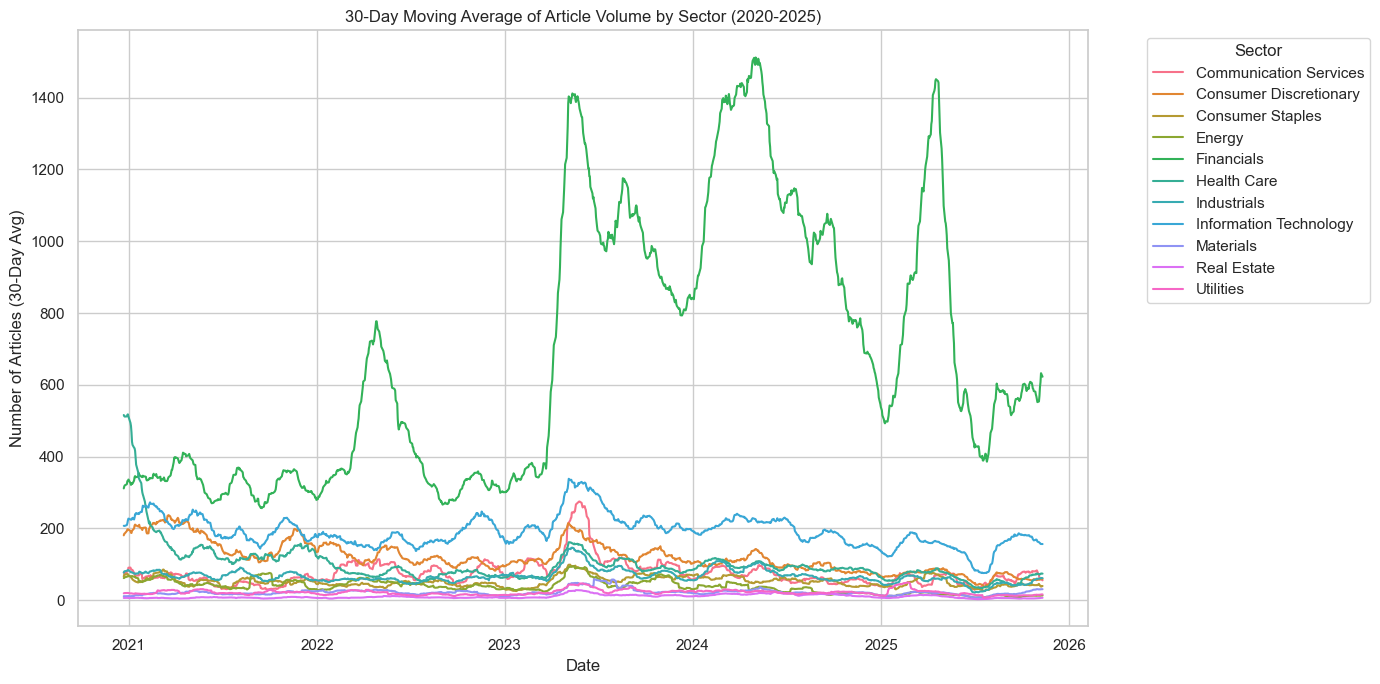

In [ ]:
# Group by Date and Sector, summing the daily articles to get the total per sector per day
daily_sector_articles = df_timeframe.groupby(['Date', 'Sector'])['article_count'].sum().reset_index()

# Pivot the dataframe so Dates are the index and Sectors are the columns
pivot_articles = daily_sector_articles.pivot(index='Date', columns='Sector', values='article_count')

# Apply a 30-day rolling average to smooth the data for readability
smoothed_articles = pivot_articles.rolling(window=30).mean()

# Create the line plot
plt.figure(figsize=(14, 7))
sns.lineplot(data=smoothed_articles, dashes=False, linewidth=1.5)

plt.title('30-Day Moving Average of Article Volume by Sector (2020-2025)')
plt.xlabel('Date')
plt.ylabel('Number of Articles (30-Day Avg)')

# Move the legend outside the plot so it doesn't cover the data lines
plt.legend(title='Sector', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

C:\Users\jplac\AppData\Local\Temp\ipykernel_19184\2916790351.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  daily_sector_returns = df_year.groupby(['Date', 'Sector'])['daily_return'].mean().reset_index()


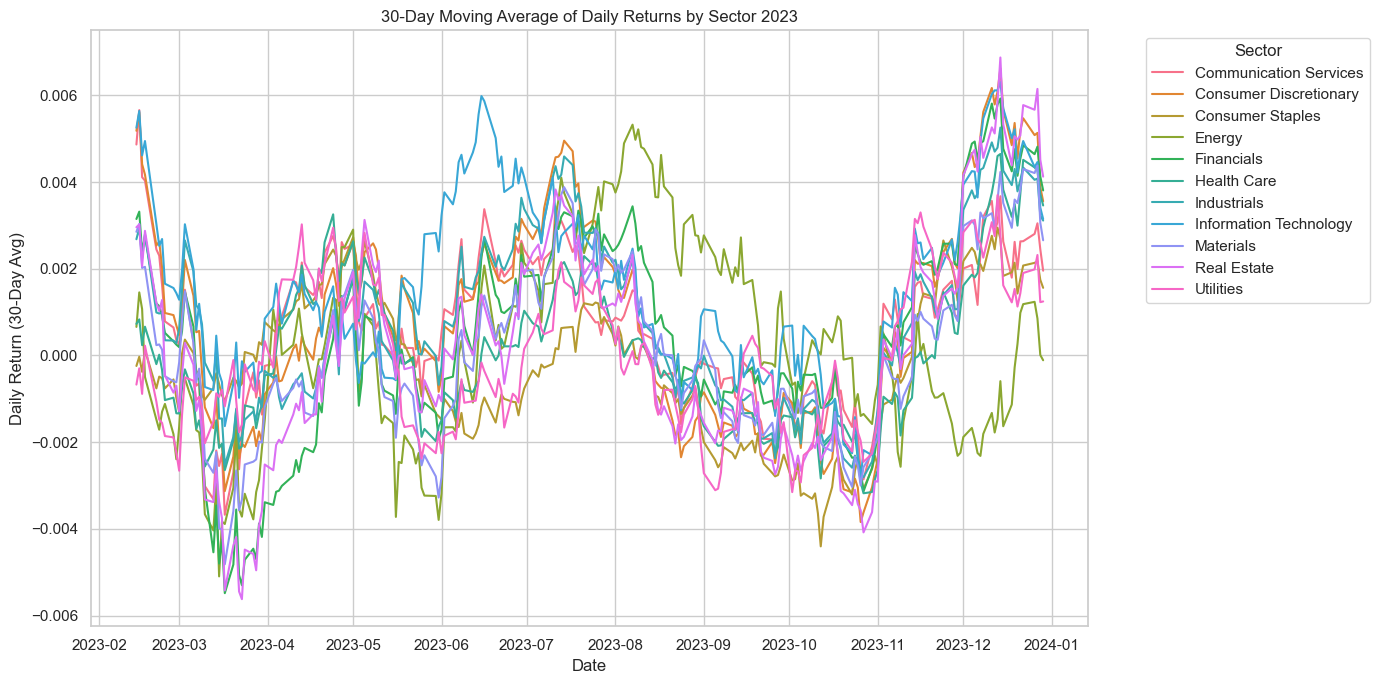

C:\Users\jplac\AppData\Local\Temp\ipykernel_19184\2916790351.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_15_industries_20 = df_year.groupby('Industry')['article_count'].sum().nlargest(top_n).index.tolist()


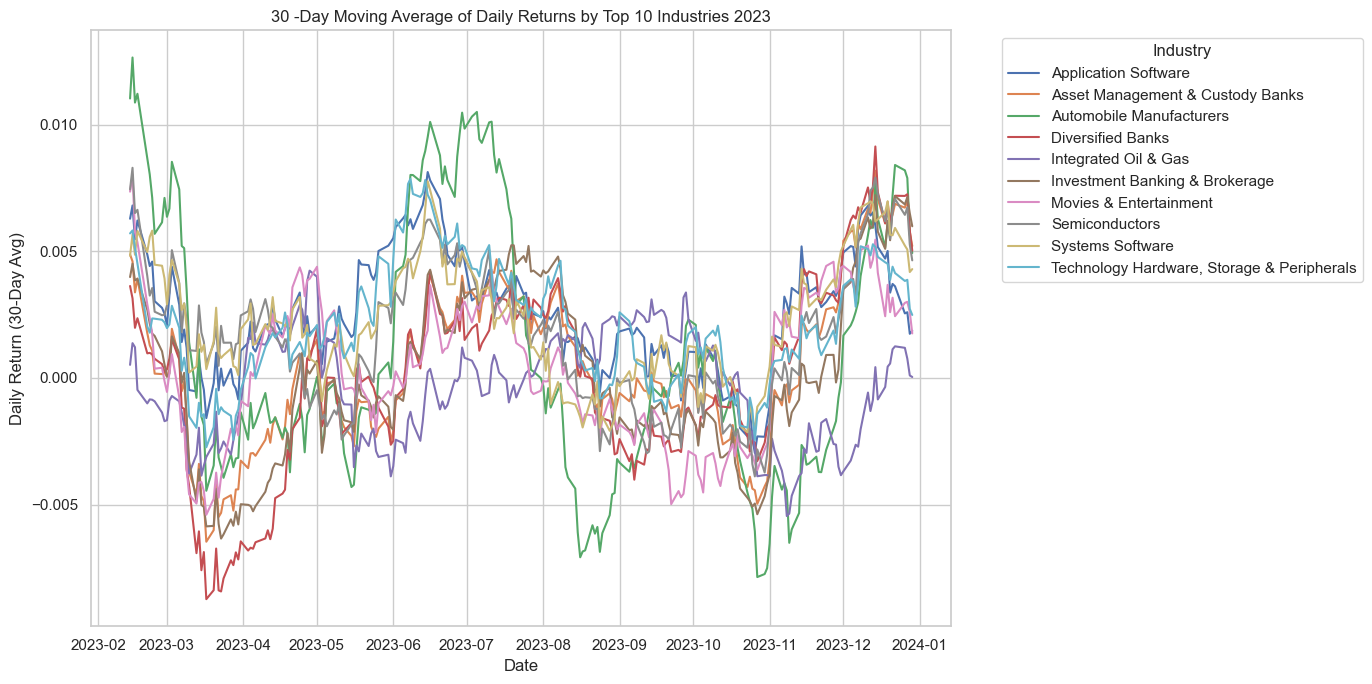

In [62]:
year = 2023
start_date = pd.to_datetime(f'{year}-01-01')
end_date = pd.to_datetime(f'{year}-12-31')
df_year = df[(df['Date'] >= start_date) & (df['Date'] <= end_date)].copy()

moving_avg_period = 30

# print(f"New dataset created. Total rows for {year}: {len(df_timeframe)}")


# ---------------------------------------------------------
# PLOT 1: 15-Day Moving Average of Daily Returns by Sector
# ---------------------------------------------------------

# 1. Calculate the mean daily return for each sector on each day
daily_sector_returns = df_year.groupby(['Date', 'Sector'])['daily_return'].mean().reset_index()

# 2. Pivot so Date is the index and Sectors are the columns
pivot_sector_returns = daily_sector_returns.pivot(index='Date', columns='Sector', values='daily_return')

# 3. Apply a 15-day rolling average to smooth the volatility
smoothed_sector_returns = pivot_sector_returns.rolling(window=moving_avg_period).mean()

# 4. Create the line plot
plt.figure(figsize=(14, 7))
sns.lineplot(data=smoothed_sector_returns, dashes=False, linewidth=1.5)

plt.title(f'{moving_avg_period}-Day Moving Average of Daily Returns by Sector {year}')
plt.xlabel('Date')
plt.ylabel(f'Daily Return ({moving_avg_period}-Day Avg)')
plt.legend(title='Sector', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# PLOT 2: Moving Average of Daily Returns (by period window) by Top Industries
# ---------------------------------------------------------

top_n = 10

# 1. Identify Top 15 Industries by total article volume within the 2020-2024 timeframe
top_15_industries_20 = df_year.groupby('Industry')['article_count'].sum().nlargest(top_n).index.tolist()

# 2. Filter the dataset and make a copy to avoid warnings
df_top15_ind_20 = df_year[df_year['Industry'].isin(top_15_industries_20)].copy()

# THE FIX: Convert 'Industry' to standard strings so pandas forgets the other industries!
df_top15_ind_20['Industry'] = df_top15_ind_20['Industry'].astype(str)

# 3. Calculate mean daily return for each industry on each day
daily_industry_returns_20 = df_top15_ind_20.groupby(['Date', 'Industry'])['daily_return'].mean().reset_index()

# 4. Pivot so Date is the index and Industries are the columns
pivot_industry_returns_20 = daily_industry_returns_20.pivot(index='Date', columns='Industry', values='daily_return')

# 5. Apply the 15-day rolling average
smoothed_industry_returns_20 = pivot_industry_returns_20.rolling(window=moving_avg_period).mean()

# 6. Create the line plot
plt.figure(figsize=(14, 7))
sns.lineplot(data=smoothed_industry_returns_20, dashes=False, linewidth=1.5)

plt.title(f'{moving_avg_period} -Day Moving Average of Daily Returns by Top {top_n} Industries {year}')
plt.xlabel('Date')
plt.ylabel(f'Daily Return ({moving_avg_period}-Day Avg)')
plt.legend(title='Industry', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [63]:
df.head()

,Date,Ticker,Company,Sector,Industry,Open,High,Low,Close,Volume,avg_sentiment,article_count,daily_return,daily_vol,daily_price_direction,daily_volume_direction,target_next_day_direction
0,2015-02-19,A,Agilent Technologies Inc,Health Care,Life Sciences Tools & Services,37.889730,38.045314,37.560253,37.660927,3737300,-0.884512,3,-0.009388,-0.585076,-1,-1,1
1,2015-02-20,A,Agilent Technologies Inc,Health Care,Life Sciences Tools & Services,37.606019,38.539534,37.413825,38.393101,2971900,0.590905,2,0.019441,-0.204800,1,-1,0
2,2015-02-23,A,Agilent Technologies Inc,Health Care,Life Sciences Tools & Services,38.338183,38.402248,37.972101,38.191750,1967900,0.000000,1,-0.005244,-0.337831,-1,-1,1
3,2015-02-24,A,Agilent Technologies Inc,Health Care,Life Sciences Tools & Services,38.091068,38.539523,38.072763,38.493763,1922100,0.351906,1,0.007908,-0.023274,1,-1,1
4,2015-02-25,A,Agilent Technologies Inc,Health Care,Life Sciences Tools & Services,38.750024,38.887307,38.521221,38.621895,2343500,-0.291386,3,0.003329,0.219239,1,1,1


In [64]:
# Code Prior to using using Groupedby method

# df = sp500_original.copy()

# # Feature Engineering (Crucial for improved accuracy)

# # Add Short-term moving average
# df.ta.sma(length=3, append=True)
# df.ta.sma(length=5, append=True)

# # Add moving averages, RSI, MACD, and Bollinger Bands using pandas-ta
# df.ta.sma(length=20, append=True)
# df.ta.sma(length=50, append=True)
# df.ta.rsi(length=14, append=True)
# df.ta.macd(fast=12, slow=26, signal=9, append=True)
# df.ta.bbands(length=20, append=True)

# # Add momentum features (e.g., % change in close price, % change in volume)
# df['daily_return'] = df.groupby('Ticker')['Close'].pct_change()
# df['vol_change'] = df.groupby('Ticker')['Volume'].pct_change()

# # 3. Define the Target Variable (Direction)
# # 1 if tomorrow's close is higher than today's close, else 0
# df['target'] = (df.groupby('Ticker')['Close'].shift(-1) > df.groupby('Ticker')['Close']).astype(int)

# # Drop NaN values created by indicators and shifting
# df.dropna(inplace=True)


In [65]:
df.columns

Index(['Date', 'Ticker', 'Company', 'Sector', 'Industry', 'Open', 'High',
       'Low', 'Close', 'Volume', 'avg_sentiment', 'article_count',
       'daily_return', 'daily_vol', 'daily_price_direction',
       'daily_volume_direction', 'target_next_day_direction'],
      dtype='object')

## Train / Test Split (numerical only)

Option 1: 80/20 split
    - sorted by date not group to avoid leakage

Option 2: Rolling window method


### Option 1: 80/20 split

In [66]:
# Sort all date
df_date_sorted = df.sort_values(by='Date').copy()

# Find date point that is at 80%
unique_dates = df_date_sorted['Date'].unique()
split_index = int(len(unique_dates)*0.8)
cutoff_date = unique_dates[split_index]

# Get start and end dates
start_date = df_date_sorted['Date'].min()
end_date = df_date_sorted['Date'].max()

print(f"Data ranges from: {start_date.date()} to {end_date.date()}")
print(f"Splitting data at cutoff date: {cutoff_date}")

Data ranges from: 2015-02-19 to 2025-11-10
Splitting data at cutoff date: 2024-10-14 00:00:00


In [67]:
# Train / Test Split
train = df_date_sorted[df_date_sorted['Date'] < cutoff_date]
test = df_date_sorted[df_date_sorted['Date'] >= cutoff_date]

# Seperating features (X) and target (y)
exclude_columns = [
    'Date', 'Ticker', 'Company',   # Identifiers / Text
    'Sector', 'Industry',   # Categorical
    # 'Open', 'High', 'Low', 'Close',                     # Raw prices (use engineered features instead)
    'target_next_day_direction'                         # The target variable
]

# Separate features (X) and target (y)
X_train = train.drop(columns = exclude_columns)
y_train = train['target_next_day_direction']

X_test = test.drop(columns = exclude_columns)
y_test = test['target_next_day_direction']

# Verify the shapes
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

# Optional: Print the exact features being used to double-check
print("\nFeatures used for modeling:")
print(X_train.columns)

X_train shape: (1175001, 11)
y_train shape: (1175001,)
X_test shape: (135295, 11)
y_test shape: (135295,)

Features used for modeling:
Index(['Open', 'High', 'Low', 'Close', 'Volume', 'avg_sentiment',
       'article_count', 'daily_return', 'daily_vol', 'daily_price_direction',
       'daily_volume_direction'],
      dtype='object')


### Model: Majority and Random Baselines

In [83]:
# ==========================================
# MODEL: MAJORITY BASELINE
# ==========================================

majority_class = y_train.mode()[0]
y_pred_majority = np.full(len(y_test), majority_class)

# The probability of class 1 is simply 1.0 if majority is 1, else 0.0
y_prob_majority = np.full(len(y_test), majority_class)

print("\n=== MAJORITY BASELINE ===")
print(f"Accuracy:    {accuracy_score(y_test, y_pred_majority):.4f}")
print(f"Precision:   {precision_score(y_test, y_pred_majority, zero_division=0):.4f}")
print(f"Recall:      {recall_score(y_test, y_pred_majority, zero_division=0):.4f}")
print(f"F1 Score:    {f1_score(y_test, y_pred_majority, zero_division=0):.4f}")
print(f"ROC-AUC:     {roc_auc_score(y_test, y_prob_majority):.4f}")
print(f"Log Loss:    {log_loss(y_test, y_prob_majority):.4f}")
print(f"Brier Score: {brier_score_loss(y_test, y_prob_majority):.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_majority))


# ==========================================
# MODEL: RANDOM BASELINE
# ==========================================

p = y_train.mean() # The historical probability of Class 1 ('Up')
y_pred_random = np.random.binomial(1, p, size=len(y_test))

# The predicted probability of class 1 is just the historical mean 'p' for all rows
y_prob_random = np.full(len(y_test), p)

print("\n=== RANDOM BASELINE ===")
print(f"Accuracy:    {accuracy_score(y_test, y_pred_random):.4f}")
print(f"Precision:   {precision_score(y_test, y_pred_random, zero_division=0):.4f}")
print(f"Recall:      {recall_score(y_test, y_pred_random, zero_division=0):.4f}")
print(f"F1 Score:    {f1_score(y_test, y_pred_random, zero_division=0):.4f}")
print(f"ROC-AUC:     {roc_auc_score(y_test, y_prob_random):.4f}")
print(f"Log Loss:    {log_loss(y_test, y_prob_random):.4f}")
print(f"Brier Score: {brier_score_loss(y_test, y_prob_random):.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_random))


=== MAJORITY BASELINE ===
Accuracy:    0.5109
Precision:   0.5109
Recall:      1.0000
F1 Score:    0.6763
ROC-AUC:     0.5000
Log Loss:    17.6303
Brier Score: 0.4891
Confusion Matrix:
 [[    0 66178]
 [    0 69117]]

=== RANDOM BASELINE ===
Accuracy:    0.5000
Precision:   0.5103
Recall:      0.5261
F1 Score:    0.5181
ROC-AUC:     0.5000
Log Loss:    0.6933
Brier Score: 0.2501
Confusion Matrix:
 [[31290 34888]
 [32756 36361]]


### Model: Random Forest (Initial - Numeric Only)

In [ ]:
# Preparing parameters for cross-validation
tscv = TimeSeriesSplit(n_splits=5)
param_grid = {
    'n_estimators': [100, 200],         # Number of trees
    'max_depth': [10, 20],              # Maximum depth to prevent overfitting
    'min_samples_leaf': [10, 50]        # Minimum samples in a leaf to ensure generalizable rules
}

# Initialize the Random Forest model
# n_jobs=-1 ensures it uses all available processors to handle the large dataset
rf_model = RandomForestClassifier(random_state=42, n_jobs=-1)

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=tscv,
    scoring='roc_auc',  # pick the best model based on AUC, not just raw accuracy
    verbose=2,          # Prints progress updates as it trains
    n_jobs=-1           # Runs parallel combinations if your CPU supports it
)

# Run the Grid Search on the Training Data
print("Starting GridSearchCV... (Grab a coffee, this will take some time!)")
grid_search.fit(X_train, y_train)

# Extract the Best Parameters and the Best Model
print("\n--- GRID SEARCH COMPLETE ---")
print(f"Best Hyperparameters: {grid_search.best_params_}")
print(f"Best Cross-Validation AUC: {grid_search.best_score_:.4f}")

best_rf_model = grid_search.best_estimator_

# Make predictions on the test set
print("Making predictions on the test set...")
y_pred = best_rf_model.predict(X_test)                  # Hard predictions (0 or 1)
y_pred_proba = best_rf_model.predict_proba(X_test)[:, 1]  # Probabilities for class 1 ('Up')


Starting GridSearchCV... (Grab a coffee, this will take some time!)
Fitting 5 folds for each of 8 candidates, totalling 40 fits

--- GRID SEARCH COMPLETE ---
Best Hyperparameters: {'max_depth': 10, 'min_samples_leaf': 50, 'n_estimators': 100}
Best Cross-Validation AUC: 0.5075
Making predictions on the test set...


In [ ]:
# Calculate all metrics
accuracy = accuracy_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_pred_proba)
ll_score = log_loss(y_test, y_pred_proba)
brier_score = brier_score_loss(y_test, y_pred_proba)

# 7. Display the comprehensive results
print("\n--- BASELINE MODEL PERFORMANCE ---")
print(f"Accuracy:    {accuracy:.4f}")
print(f"ROC-AUC:     {auc_score:.4f}")
print(f"Log Loss:    {ll_score:.4f}")
print(f"Brier Score: {brier_score:.4f}")

print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred))

print("--- CONFUSION MATRIX ---")
# Calculate and print the raw confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm_table = pd.DataFrame(
    cm, 
    index=['Actual 0', 'Actual 1'], 
    columns=['Predicted 0', 'Predicted 1']
)
print(cm_table)


--- BASELINE MODEL PERFORMANCE ---
Accuracy:    0.5117
ROC-AUC:     0.5067
Log Loss:    0.6933
Brier Score: 0.2501

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.51      0.05      0.10     66178
           1       0.51      0.95      0.67     69117

    accuracy                           0.51    135295
   macro avg       0.51      0.50      0.38    135295
weighted avg       0.51      0.51      0.39    135295

--- CONFUSION MATRIX ---
          Predicted 0  Predicted 1
Actual 0         3620        62558
Actual 1         3505        65612


--- FEATURE IMPORTANCE SCORES ---
               Feature  Importance
          daily_return    0.257753
             daily_vol    0.150618
                Volume    0.122320
                 Close    0.080613
                  High    0.080467
                  Open    0.080436
                   Low    0.075233
         avg_sentiment    0.067399
 daily_price_direction    0.041046
         article_count    0.034800
daily_volume_direction    0.009314


C:\Users\jplac\AppData\Local\Temp\ipykernel_19184\2488692366.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


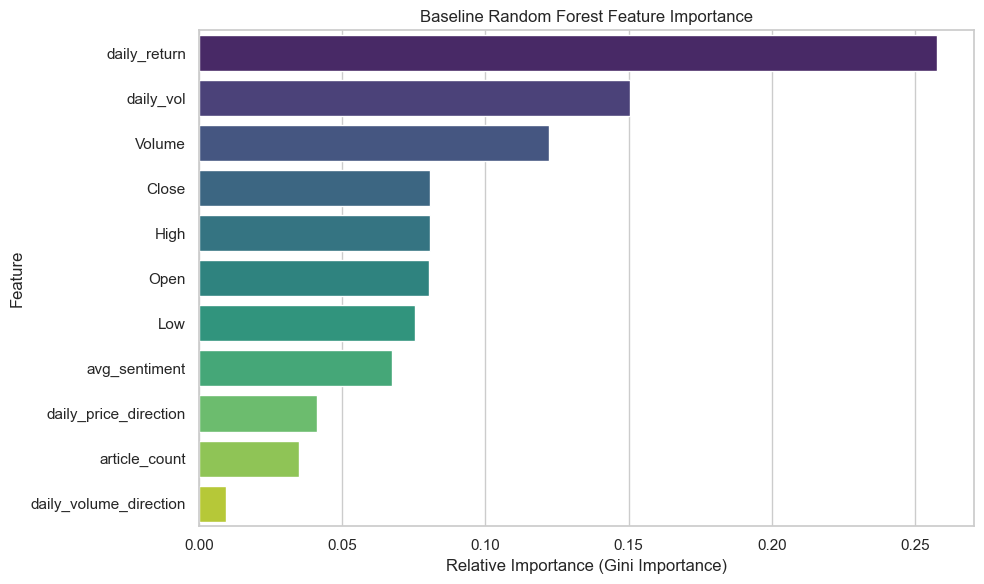

In [74]:
# Extract the feature names and importances from best tuned model
feature_names = best_rf_model.feature_names_in_
importances = best_rf_model.feature_importances_

# Create a DataFrame pairing the feature names with their importance scores
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Display the exact numeric values
print("--- FEATURE IMPORTANCE SCORES ---")
print(feature_importance_df.to_string(index=False))

# Create a horizontal bar chart for visualization
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')

plt.title('Baseline Random Forest Feature Importance')
plt.xlabel('Relative Importance (Gini Importance)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Model: XGBoost Classifier (Initial - Numeric Only)

In [75]:
# Seperating features (X) and target (y)
exclude_columns_xgb = [
    'Date', 'Ticker', 'Company',        # Identifiers / Text
    'Sector', 'Industry',               # Categorical (Exclude them in Numerical, but include them in combinational)
    # 'Open', 'High', 'Low', 'Close',     # Raw prices (Include initially, but exclude afterwards)
    'target_next_day_direction'         # The target variable
]

# Separate features (X) and target (y)
X_train_xgb = train.drop(columns = exclude_columns_xgb)
y_train_xgb = train['target_next_day_direction']

X_test_xgb = test.drop(columns = exclude_columns_xgb)
y_test_xgb = test['target_next_day_direction']

# Optional: Print the exact features being used to double-check
print("\nFeatures used for modeling:")
print(X_train_xgb.columns)


Features used for modeling:
Index(['Open', 'High', 'Low', 'Close', 'Volume', 'avg_sentiment',
       'article_count', 'daily_return', 'daily_vol', 'daily_price_direction',
       'daily_volume_direction'],
      dtype='object')


## Model: XGBoost Classifier (Numerical)

In [ ]:
# Defining parameters
tscv_xgb = TimeSeriesSplit(n_splits=5)
param_grid_xgb = {
    'n_estimators': [50, 75, 100, 150, 200],
    'max_depth': [3, 4, 5, 6, 7, 8],
    'learning_rate': [0.05, 0.1]
}

# 3. Initialize the base XGBoost model
xgb_base = XGBClassifier(
    # tree_method='hist',           # Use to include categorical
    # enable_categorical=True,      # Use to include categorical
    random_state=42,
    n_jobs=-1
)

# 4. Set up the Grid Search
grid_search_xgb = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid_xgb,
    cv=tscv_xgb,
    scoring='roc_auc',
    verbose=2,
    n_jobs=-1
)

# 5. Run the search on your training data
print("Searching for the best parameters. This may take a moment...")
grid_search_xgb.fit(X_train_xgb, y_train_xgb)


Searching for the best parameters. This may take a moment...
Fitting 5 folds for each of 72 candidates, totalling 360 fits

--- XGBOOST GRID SEARCH COMPLETE ---
Best Hyperparameters: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 50}
Best Cross-Validation AUC: 0.5077

Evaluating the Best XGBoost Model on the Test Set...


NameError: name 'best_xgb_model' is not defined

In [77]:

best_xgb_model = grid_search_xgb.best_estimator_

# best_n = grid_search.best_params_['n_estimators']
# best_d = grid_search.best_params_['max_depth']
# best_rate = grid_search.best_params_['learning_rate']

# # 6. View the results
# print(f"Best n_estimators: {best_n}")
# print(f"Best max_depth: {best_d}")
print("\n--- XGBOOST GRID SEARCH COMPLETE ---")
print(f"Best Hyperparameters: {grid_search_xgb.best_params_}")
print(f"Best Cross-Validation AUC: {grid_search_xgb.best_score_:.4f}")

# 7. Use the winning model for your final predictions
print("\nEvaluating the Best XGBoost Model on the Test Set...")
y_pred_xgb_best = best_xgb_model.predict(X_test_xgb)
y_pred_proba_xgb_best = best_xgb_model.predict_proba(X_test_xgb)[:, 1]


--- XGBOOST GRID SEARCH COMPLETE ---
Best Hyperparameters: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 50}
Best Cross-Validation AUC: 0.5077

Evaluating the Best XGBoost Model on the Test Set...


In [79]:
# Calculate all metrics
accuracy_xgb = accuracy_score(y_test_xgb, y_pred_xgb_best)
auc_score_xgb = roc_auc_score(y_test_xgb, y_pred_proba_xgb_best)
ll_score_xgb = log_loss(y_test_xgb, y_pred_proba_xgb_best)
brier_score_xgb = brier_score_loss(y_test_xgb, y_pred_proba_xgb_best)

# 7. Display the comprehensive results
print("\n--- BASELINE MODEL PERFORMANCE (XGB) ---")
print(f"Accuracy:    {accuracy_xgb:.4f}")
print(f"ROC-AUC:     {auc_score_xgb:.4f}")
print(f"Log Loss:    {ll_score_xgb:.4f}")
print(f"Brier Score: {brier_score_xgb:.4f}")

print("\n--- CLASSIFICATION REPORT (XGB) ---")
print(classification_report(y_test_xgb, y_pred_xgb_best))

print("--- CONFUSION MATRIX (XGB) ---")
# Calculate and print the raw confusion matrix
cm_xgb = confusion_matrix(y_test_xgb, y_pred_xgb_best)
cm_table_xgb = pd.DataFrame(
    cm_xgb, 
    index=['Actual 0', 'Actual 1'], 
    columns=['Predicted 0', 'Predicted 1']
)
print(cm_table_xgb)


--- BASELINE MODEL PERFORMANCE (XGB) ---
Accuracy:    0.5122
ROC-AUC:     0.5059
Log Loss:    0.6933
Brier Score: 0.2501

--- CLASSIFICATION REPORT (XGB) ---
              precision    recall  f1-score   support

           0       0.51      0.05      0.10     66178
           1       0.51      0.95      0.67     69117

    accuracy                           0.51    135295
   macro avg       0.51      0.50      0.38    135295
weighted avg       0.51      0.51      0.39    135295

--- CONFUSION MATRIX (XGB) ---
          Predicted 0  Predicted 1
Actual 0         3492        62686
Actual 1         3306        65811


NOTE: True Negative improved, while True Positive decreased

--- FEATURE IMPORTANCE SCORES ---
               Feature  Importance
          daily_return    0.258271
             daily_vol    0.152794
                 Close    0.105800
                  Open    0.100452
                Volume    0.094125
                  High    0.078030
                   Low    0.072451
         avg_sentiment    0.070095
         article_count    0.067982
 daily_price_direction    0.000000
daily_volume_direction    0.000000


C:\Users\jplac\AppData\Local\Temp\ipykernel_19184\3061487930.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df_xgb, palette='viridis')


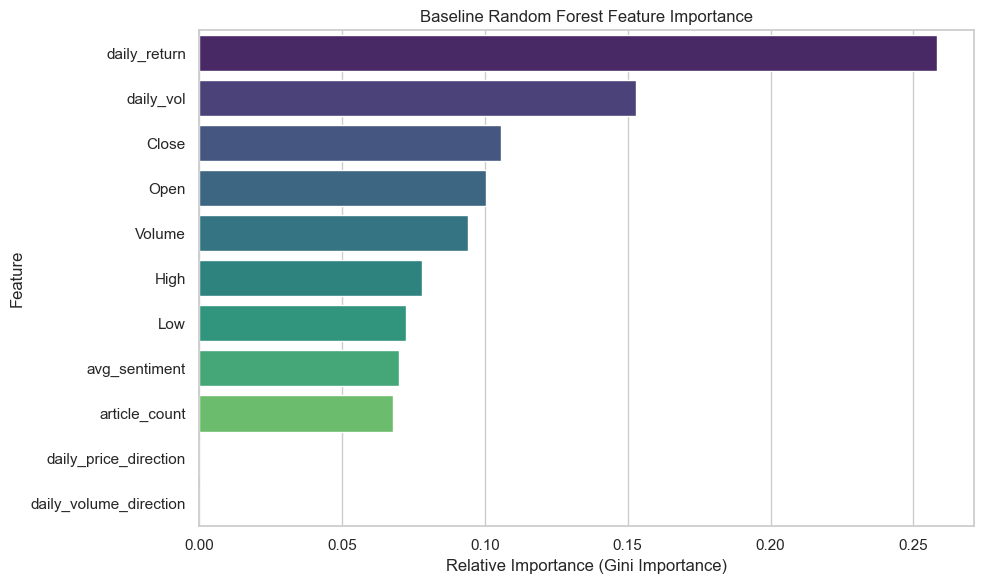

In [81]:
# Extract the feature names and importances from best tuned model
feature_names_xgb = best_xgb_model.feature_names_in_
importances_xgb = best_xgb_model.feature_importances_

# Create a DataFrame pairing the feature names with their importance scores
feature_importance_df_xgb = pd.DataFrame({
    'Feature': feature_names_xgb,
    'Importance': importances_xgb
}).sort_values(by='Importance', ascending=False)

# Display the exact numeric values
print("--- FEATURE IMPORTANCE SCORES ---")
print(feature_importance_df_xgb.to_string(index=False))

# Create a horizontal bar chart for visualization
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df_xgb, palette='viridis')

plt.title('Baseline Random Forest Feature Importance')
plt.xlabel('Relative Importance (Gini Importance)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

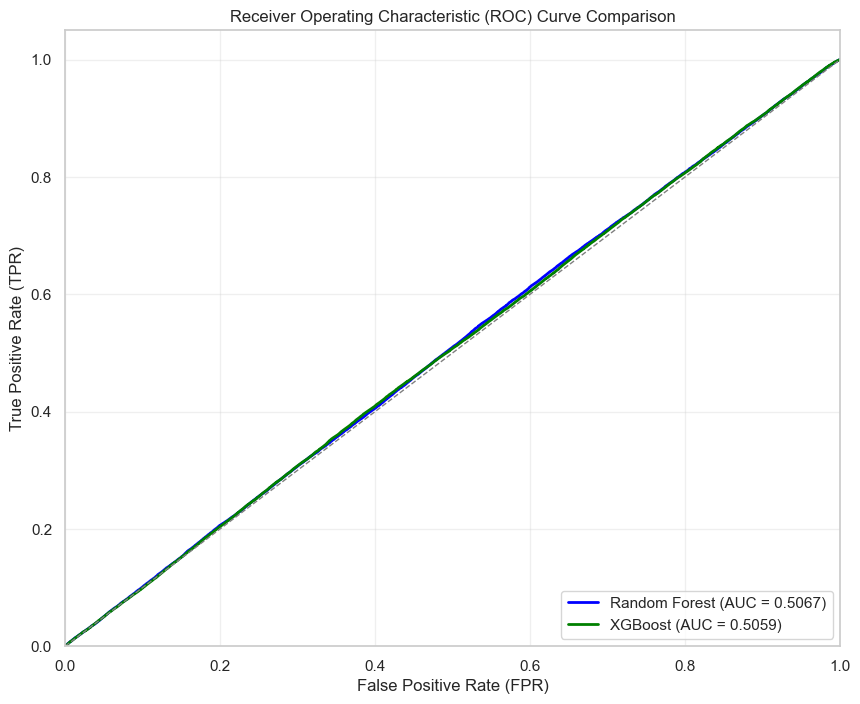

In [80]:
# ROC Comparison
from sklearn.metrics import roc_curve, auc

# --- Calculate ROC Curve for Random Forest ---
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# --- Calculate ROC Curve for XGBoost ---
fpr_xgb, tpr_xgb, _ = roc_curve(y_test_xgb, y_pred_proba_xgb_best)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

# --- Plotting the ROC Curves ---
plt.figure(figsize=(10, 8))

# Plot Random Forest ROC
plt.plot(fpr_rf, tpr_rf, color='blue', lw=2, 
         label=f'Random Forest (AUC = {roc_auc_rf:.4f})')

# Plot XGBoost ROC
plt.plot(fpr_xgb, tpr_xgb, color='green', lw=2, 
         label=f'XGBoost (AUC = {roc_auc_xgb:.4f})')

# Plot the diagonal line for random guessing
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')

# --- Formatting the Plot ---
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

## Model: XGBoost Classifier (Numerical + Categorical)

In [ ]:
# Selecting numerical columns AND our new category columns
features_to_keep = df.select_dtypes(include=['number', 'category']).columns
features_to_keep = features_to_keep.drop(['target', 'Close', 'Open', 'High', 'Low'], errors='ignore')

X = df[features_to_keep]
y = df['target']

print(X.columns)

split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# --- UPDATE TO STEP 5: Train the Model ---
# We MUST add enable_categorical=True and use the 'hist' tree method
model = xgb.XGBClassifier(
    n_estimators=200, 
    max_depth=6, 
    learning_rate=0.05, 
    random_state=42,
    tree_method='hist',           # Required for categorical data
    enable_categorical=True       # The magic switch!
)
model.fit(X_train, y_train)

In [ ]:
pred_cat = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, pred_cat):.2f}")
print(classification_report(y_test, pred_cat))

# Calculate and print the raw confusion matrix
cm_cat = confusion_matrix(y_test, pred_cat)
cm_cat_table = pd.DataFrame(
    cm_cat, 
    index=['Actual 0', 'Actual 1'], 
    columns=['Predicted 0', 'Predicted 1']
)

print("Confusion Matrix Table (Test Set):")
print(cm_cat_table)

# Get additional metrics: AUC, Log-loss, Brier score...
auc_score = roc_auc_score(y_test, predictions)
print(f"AUC Score: {auc_score:.4f}")

logloss_score = log_loss(y_test, predictions)
print(f"Log-Loss: {logloss_score:.4f}")

brier_score = brier_score_loss(y_test, predictions)
print(f"Brier Score: {brier_score:.4f}")

In [ ]:
# 7. Visualize Feature Importance
# We use 'gain' to see which features actually improved accuracy the most
plt.figure(figsize=(10, 8))

# plot_importance is built directly into the xgboost library
xgb.plot_importance(
    model, 
    importance_type='gain', 
    max_num_features=15,       # Change this to see more or fewer features
    show_values=False,         # Hides the raw numbers on the bars for a cleaner look
    title='Top 15 Features by Information Gain'
)

plt.tight_layout()
plt.show()

# Optional: Print the exact numerical scores for 'gain'
importance_scores = model.get_booster().get_score(importance_type='gain')
# Sort the dictionary by value in descending order
sorted_importance = dict(sorted(importance_scores.items(), key=lambda item: item[1], reverse=True))

print("\nExact Feature Importance Scores (Gain):")
for feature, score in list(sorted_importance.items())[:10]: # Print top 10
    print(f"{feature}: {score:.4f}")

NOTE: Features show model priorities 


---

# Checking tomorrow's prices

- narrowing down to one company to see how things are looking

In [ ]:
# creating seperate dataframe to work on
sp500 = sp500_original.copy()

# testing using only one company
sp500_A = sp500[sp500['Ticker'] == 'A'].copy()

# Round the price columns to two decimal places
sp500_A[['Open', 'High', 'Low', 'Close']] = sp500_A[['Open', 'High', 'Low', 'Close']].round(2)

# You can then display the head of the DataFrame to see the changes
print(sp500_A.shape)
sp500_A.head()

## Adding additional columns for analysis

In [ ]:
# Next Day Price
sp500_A["next_day_price"] = sp500_A["Close"].shift(-1)

# Next Day Price Direction (1 if price increase, 0 if no change or decrease)
sp500_A["price_direction"] = (sp500_A["next_day_price"] > sp500_A["Close"]).astype(int)
# sp500_A.head()

# Daily Percentage Return
sp500_A['daily_return'] = sp500_A['Close'].pct_change()

# Moving Averages (e.g., 5-day and 20-day)
sp500_A['SMA_3'] = sp500_A['Close'].rolling(window=3).mean()    # 3 day moving average
sp500_A['SMA_5'] = sp500_A['Close'].rolling(window=5).mean()    # 5 day (1 week) moving average
sp500_A['SMA_5'] = sp500_A['Close'].rolling(window=10).mean()   # 10 day (2 weeks) moving average
sp500_A['SMA_20'] = sp500_A['Close'].rolling(window=21).mean()  # 21 day (1 month) Moving average

# Ratio of current price to Moving Average
sp500_A['Close_to_SMA_20'] = sp500_A['Close'] / sp500_A['SMA_20']

# Volatility (High-Low spread percentage)
sp500_A['volatility'] = (sp500_A['High'] - sp500_A['Low']) / sp500_A['Open']

# Lagged price direction (what did it do yesterday?)
sp500_A['prev_direction'] = sp500_A['price_direction'].shift(1)

# Calculate the 12-day EMA
ema_12 = sp500_A['Close'].ewm(span=12, adjust=False).mean()

# Calculate the 26-day EMA
ema_26 = sp500_A['Close'].ewm(span=26, adjust=False).mean()

# Calculate the MACD Line
sp500_A['MACD_line'] = ema_12 - ema_26

# Calculate the Signal Line (9-day EMA of the MACD line)
sp500_A['MACD_signal'] = sp500_A['MACD_line'].ewm(span=9, adjust=False).mean()

# The MACD Histogram (the difference between the two)
sp500_A['MACD_histogram'] = sp500_A['MACD_line'] - sp500_A['MACD_signal']

sp500_A.shape


In [ ]:
missing_summary = (
    sp500_A.isna()
    .sum()
    .loc[lambda s: s > 0]
    .sort_values(ascending=False)
    .rename("missing_count")
    .reset_index()
    .rename(columns={"index": "column"})
)

print(missing_summary)

print("Columns with missing values:", missing_summary.shape[0])

In [ ]:
# Rows that will be removed by dropna (because they contain at least one missing value)
removed_rows = sp500_A[sp500_A.isna().any(axis=1)].copy()

# Final dataframe after removing missing rows
df = sp500_A.dropna().copy()

# Count check
print("Original rows:", len(sp500_A))
print("Rows removed:", len(removed_rows))
print("Rows remaining:", len(df))

# Show removed rows
# print(removed_rows)

In [ ]:

# Drop the NaN rows created by rolling windows and shifts
# df = sp500_A.dropna().copy()


In [ ]:
# Top 5 companies by number of observations
top5 = (
    df
    .groupby(["Ticker", "Company"], as_index=False)
    .size()
    .rename(columns={"size": "row_count"})
    .sort_values("row_count", ascending=False)
    .head(5)
    .reset_index(drop=True)
)

print(top5)

## Sentiment Analysis

In [ ]:
# # gdelt 2.0 starts at February 18 2025. Use gdelt 1.0 for dates prior. 1.0 is limited...

# # Ensure Date is datetime before comparing to cutoff_date
# df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
# df = df.dropna(subset=["Date"])

# # rows get dropped after cutoff_date
# cutoff_date = pd.Timestamp("2020-02-18")
# df = df.loc[df["Date"] > cutoff_date].copy()
# print("Dataset with new date range:")
# print(df.shape)

# df_sentiment = get_daily_sentiment_chunked(
#     df,
#     ticker=df["Ticker"].dropna().iloc[0],
#     company_name=df["Company"].dropna().iloc[0]
# )


In [ ]:
# df_sentiment.shape

In [ ]:
# print(df_sentiment.shape)
# df_sentiment.head()

## CandleStick and MACD Plot

In [ ]:
# candlestick + MACD strategy plot (past 60 days) using df

import matplotlib.dates as mdates
from mplfinance.original_flavor import candlestick_ohlc

plot_df = df_sentiment.copy()

#Ensure we have a datetime index
if "Date" in plot_df.columns:
    plot_df["Date"] = pd.to_datetime(plot_df["Date"], errors="coerce")
    plot_df = plot_df.dropna(subset=["Date"]).set_index("Date")
else:
    plot_df.index = pd.to_datetime(plot_df.index, errors="coerce")
    plot_df = plot_df[~plot_df.index.isna()]

plot_df = plot_df.sort_index()

# Required columns check
required_cols = ["Open", "High", "Low", "Close", "MACD_line", "MACD_signal", "MACD_histogram"]
missing = [c for c in required_cols if c not in plot_df.columns]
if missing:
    raise ValueError(f"Missing required columns in df: {missing}")

# Keep last 60 rows
last60 = plot_df[required_cols].tail(60).copy()

# MACD crossover signals
macd_above = last60["MACD_line"] > last60["MACD_signal"]
last60["signal"] = 0
last60.loc[macd_above & (~macd_above.shift(1, fill_value=False)), "signal"] = 1   # buy
last60.loc[(~macd_above) & macd_above.shift(1, fill_value=False), "signal"] = -1  # sell
last60["position"] = (last60["MACD_line"] > last60["MACD_signal"]).astype(int)

buy_pts = last60[last60["signal"] == 1]
sell_pts = last60[last60["signal"] == -1]

# 5) Build OHLC data for candlestick_ohlc
ohlc = last60.reset_index()[["Date", "Open", "High", "Low", "Close"]].copy()
ohlc["Date"] = mdates.date2num(ohlc["Date"])

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(14, 8), sharex=True, gridspec_kw={"height_ratios": [2, 1]}
)

# Candlesticks
candlestick_ohlc(
    ax1,
    ohlc.values,
    width=0.6,             # candle body width in "days"
    colorup="green",
    colordown="red",
    alpha=0.85
)

# Buy/sell markers
ax1.scatter(buy_pts.index, buy_pts["Close"], marker="^", s=90, color="green", label="Buy")
ax1.scatter(sell_pts.index, sell_pts["Close"], marker="v", s=90, color="red", label="Sell")
ax1.set_title("Candlestick + MACD Strategy (Past 60 Days)")
ax1.set_ylabel("Price")
ax1.legend(loc="upper left")
ax1.grid(alpha=0.3)

# MACD panel
bar_colors = np.where(last60["MACD_histogram"] >= 0, "seagreen", "tomato")
ax2.bar(last60.index, last60["MACD_histogram"], color=bar_colors, alpha=0.35, label="MACD Histogram")
ax2.plot(last60.index, last60["MACD_line"], label="MACD Line", color="blue", linewidth=1.4)
ax2.plot(last60.index, last60["MACD_signal"], label="Signal Line", color="orange", linewidth=1.4)
ax2.plot(last60.index, last60["position"], label="Position", color="purple", linestyle="--", alpha=0.8)
ax2.axhline(0, color="gray", linewidth=1)
ax2.set_ylabel("MACD / Position")
ax2.set_xlabel("Date")
ax2.legend(loc="upper left")
ax2.grid(alpha=0.3)

# Date formatting
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax2.xaxis.set_major_locator(mdates.AutoDateLocator())
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

## Random Forest

In [ ]:

# feature_columns = ['Open', 'High', 'Low', 'Close', 'Volume']
# feature_columns = ['Open', 'High', 'Low', 'Close', 'Volume', 'daily_return', 'SMA_5', 'SMA_20', 'Close_to_SMA_20', 'volatility', 'prev_direction', 'MACD_line', 'MACD_signal', 'MACD_histogram']
feature_columns = ['daily_return', 'SMA_5', 'SMA_20', 'Close_to_SMA_20', 'volatility', 'prev_direction', 'MACD_line', 'MACD_signal', 'MACD_histogram', 'daily_sentiment', 'daily_news_count']
X = df_sentiment[feature_columns]
y = df_sentiment['price_direction']
print(X)


In [ ]:
# Perform an 80-10-10 Chronological Split
total_rows = len(df_sentiment)
train_end = int(total_rows * 0.8)
val_end = int(total_rows * 0.9) # 80% + 10%

X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

X_val = X.iloc[train_end:val_end]
y_val = y.iloc[train_end:val_end]

X_test = X.iloc[val_end:]
y_test = y.iloc[val_end:]

# Initialize and train the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=300, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions and evaluate on the Validation set
val_predictions = rf_model.predict(X_val)
print("--- Validation Set Performance ---")
print("Accuracy:", accuracy_score(y_val, val_predictions))

# Make predictions and evaluate on the Test set
test_predictions = rf_model.predict(X_test)
print("\n--- Test Set Performance ---")
print("Accuracy:", accuracy_score(y_test, test_predictions))


In [ ]:
print(X_train.shape, X_val.shape, X_test.shape)


In [ ]:
# Calculate and print the raw confusion matrix
cm = confusion_matrix(y_val, val_predictions)
print("Confusion Matrix (Validation Set):")
# print(cm)

cm_table = pd.DataFrame(
    cm, 
    index=['Actual 0', 'Actual 1'], 
    columns=['Predicted 0', 'Predicted 1']
)

print("Confusion Matrix Table (Validation Set):")
print(cm_table)

In [ ]:
# Convert numpy predictions to a Series with the same index as y_test
test_pred_series = pd.Series(test_predictions, index=y_test.index, name="Predicted")
actual_series = y_test.rename("Actual")

test_pred_series = test_pred_series[:-50]
actual_series = actual_series[:-50]

# Combine into one DataFrame
combined = pd.concat([actual_series, test_pred_series], axis=1)

# Plot (binary class 0/1)
ax = combined.plot(
    figsize=(14, 5),
    drawstyle="steps-mid",
    linewidth=1.2,
    alpha=0.9,
    title="Test Set: Actual vs Predicted"
)
ax.set_xlabel("Date / Index")
ax.set_ylabel("Class (0=Down/No change, 1=Up)")
ax.legend()
plt.show()

### NOTES:
overnight exchanges -SP500 only open during business hours
- there are overseas market that open before US Markets open
- add in news
  - macroeconomic stuff
    - interest rates
    - inflation
- adding key components of sp500
  - key stocks
  - key sectors
    - if tech is in downturn...it is possible that 6 months later that sp500 will go down
    - (any correlation)
- increasing resolution for more accurate predictions
  - hourly
  - minute
  - tic data
- Model can get big and you can go pretty far if you want to...